In [ ]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import napari
from tkinter import filedialog as fd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
from nilearn import image
from nilearn import plotting
from scipy.ndimage import gaussian_filter
import math
import matplotlib.patches as patches

In [97]:
def mask(seg, val):
    #To extract individual tissue from segmentation nib file
    binary_mask = np.where(seg == val, 1, 0) # Integer Mask
    return binary_mask

#dataset 1
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain.nii.gz")
seg = nib.load(seg_loc).get_fdata()
"""

#dataset 2
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
"""


#IXI sample 102
'''
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/ixi/T1/102/hf/fast_pveseg.nii.gz"
csf_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/ixi/T1/102/hf/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
'''

# Validation Data - sub_0011

folder = './Data/validation_data/sub_0011/ulf' 
seg_loc = folder + "/fast_seg.nii.gz"
csf_nib = nib.load(folder + "/fast_pve_0.nii.gz")
gm_nib = nib.load(folder + "/fast_pve_1.nii.gz")
wm_nib = nib.load(folder + "/fast_pve_2.nii.gz")
img_nib = nib.load(folder + "/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
noise = nib.load(folder + "/raw.nii.gz")




#Extracting tissues
csf_masked = mask(seg,1)
gm_masked = mask(seg,2)
wm_masked = mask(seg,3)

csf = csf_masked  * img_nib.get_fdata() #* csf_nib.get_fdata()
gm = gm_masked  * img_nib.get_fdata() #* gm_nib.get_fdata()
wm = wm_masked  * img_nib.get_fdata() #* wm_nib.get_fdata()
hf = hf_img = csf + gm + wm

In [92]:
csf.shape

(112, 136, 40)

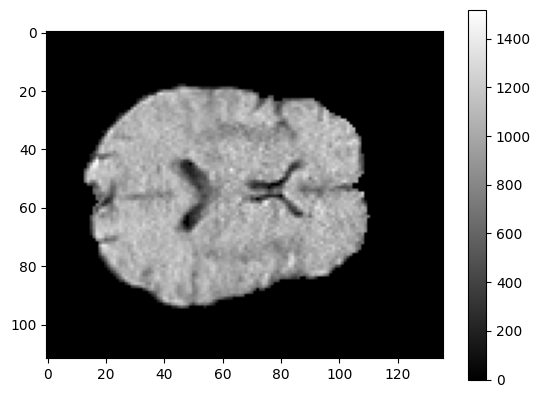

In [98]:
%matplotlib inline
slice_num = 11
plt.imshow(img_nib.get_fdata()[:,:,slice_num],cmap='gray')
plt.colorbar()
plt.show()

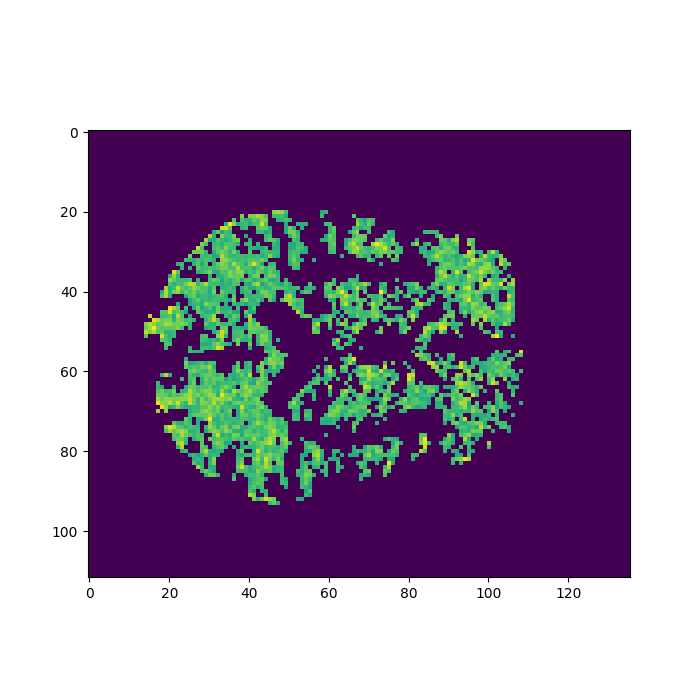

In [104]:
%matplotlib ipympl
# %matplotlib inline

import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from mpl_interactions import image_segmenter


im = Image.fromarray((wm*img_nib.get_fdata())[:,:,slice_num])
segmenter = image_segmenter(im, mask_colors="red", mask_alpha=0.99, figsize=(7, 7))
display(segmenter,colormaps='gray',colorbar=segmenter)



In [ ]:
#dataset = 1 #csf (119,82) (128,82) -> (119,85) (128,85) #gm (123, 77) (126, 79) -> (133,70) (135, 74)
#dataset = 2 #wm(135,106) (142,106) -> (135,103) (142, 103) #gm (43, 50) (47,50) -> (43, 46) (47, 46), #csf (64, 101) (83,101) -> (64,98) (83,98)

In [106]:
csf_x, csf_y, csf_w, csf_h = 54, 54, 3, 2
gm_x, gm_y, gm_w, gm_h = 61, 87, 4, 2
wm_x, wm_y, wm_w, wm_h = 41, 74, 4, 4


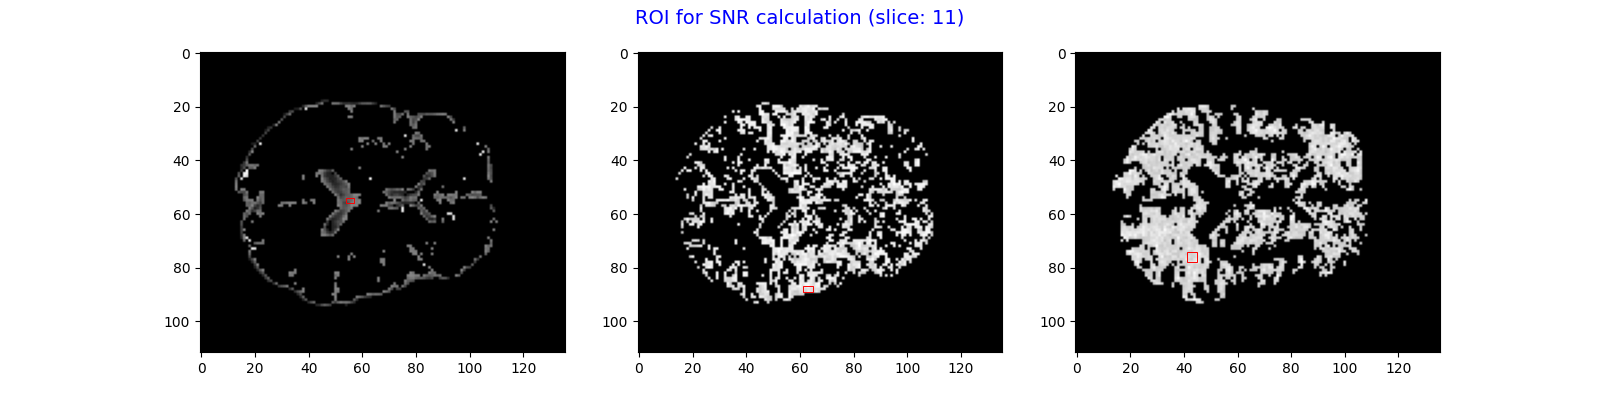

In [107]:
# %matplotlib inline
# %matplotlib ipympl

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
im1 = axs[0].imshow((csf)[:,:,slice_num],cmap='gray')# ,vmax = 1000)
im2 = axs[1].imshow((gm)[:,:,slice_num],cmap='gray')#,vmax = 800)
im3 = axs[2].imshow((wm)[:,:,slice_num],cmap='gray')#,vmax = 600)


# rect3 = patches.Rectangle((55, 69), 5, 3, linewidth=1, edgecolor='r', facecolor='none') #ms 
rect0 = patches.Rectangle((csf_x, csf_y), csf_w, csf_h, linewidth=0.7, edgecolor='r', facecolor='none') #csf 
rect1 = patches.Rectangle((gm_x, gm_y), gm_w, gm_h, linewidth=0.7, edgecolor='r', facecolor='none') #gm 
rect2 = patches.Rectangle((wm_x, wm_y), wm_w, wm_h, linewidth=0.7, edgecolor='r', facecolor='none') #wm

axs[0].add_patch(rect0)
axs[1].add_patch(rect1)
axs[2].add_patch(rect2)
# axs[3].add_patch(rect3)



fig.suptitle('ROI for SNR calculation'+ ' (slice: ' + str(slice_num) + ')', fontsize=14,color='blue')
plt.show()

In [ ]:
#dataset = 1
# csf[82:86,119:128,95]
# gm[76:80, 123:128,95]
# wm[99:109,145:155,95]
# print(wm[99:109,145:155,95].mean(), gm[76:80, 123:128,95].mean(), csf[82:86,119:128,95].mean())

#dataset = 2
# print((wm)[105:110, 132:142, 95].mean(), (gm)[45:48,43:48,95].mean(), (csf)[96:101,70:80,95].mean())

Check if there are any pixels where signal intensity = 0

In [111]:
#val data
# print(wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num])
# print(gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num])
# print(csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num])

# print(csf[104:114, 125:133, slice_num])
print("Mean signals of csf: ", csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num].mean(), "gm: ", gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num].mean(), "wm: ", wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num].mean())



Mean signals of csf:  584.6678466796875 gm:  931.1735229492188 wm:  1102.143325805664


In [112]:

#taking mean of only those samples which are 90% probabilistic


wm_roi_pixels = img_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num][wm_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num]>0.9]
gm_roi_pixels = img_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num][gm_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num]>0.9]
csf_roi_pixels = img_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num][csf_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num]>0.9]

print("Mean signals of csf: ",csf_roi_pixels.mean(), "gm: ", gm_roi_pixels.mean(), "wm: ", wm_roi_pixels.mean())


Mean signals of csf:  584.6678466796875 gm:  908.1185607910156 wm:  1102.143325805664


Noise
- Loading raw image and computing BG nosie

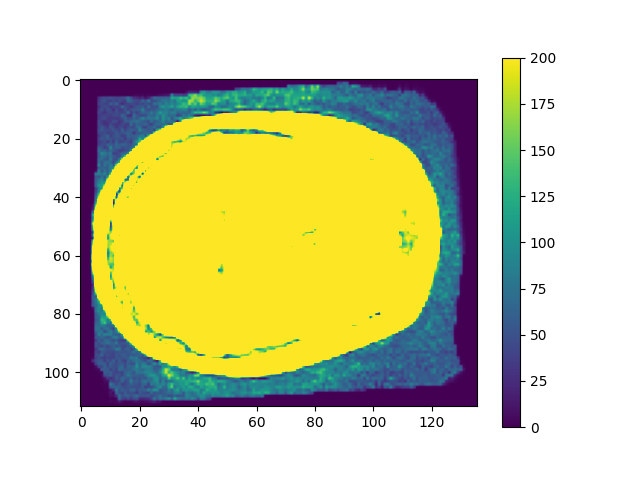

In [116]:
%matplotlib ipympl
# %matplotlib inline


plt.imshow(noise.get_fdata()[:,:,slice_num], vmax = 200)
plt.colorbar()
plt.show()


In [126]:

bg_x, bg_y, bg_w, bg_h = 116, 96, 8, 7

std_bg = noise.get_fdata()[:,:,slice_num][bg_y:bg_y+bg_h,bg_x:bg_x+bg_w, ] #region-1 #Validation data
print(std_bg)
std_bg = std_bg.std()
print(std_bg)
# std_bg = noise.get_fdata()[:,:,slice_num][28:42, 20:30, ].std() #region-1 #Validation data
# print(std_bg)
# noise.get_fdata()[:,163,:][50:60,124:138, ].std() #region-2


[[51.98809814 40.99061584 54.9874115  58.98649597 88.97962952 80.98146057
  53.98764038 61.98580933]
 [53.98764038 64.98512268 80.98146057 57.98672485 53.98764038 65.9848938
  53.98764038 52.98786926]
 [36.99153137 67.98443604 47.98901367 49.98855591 38.99107361 59.98626709
  68.98420715 53.98764038]
 [49.98855591 64.98512268 31.99267578 57.98672485 72.98329163 82.98100281
  52.98786926 62.98558044]
 [57.98672485 54.9874115  53.98764038 51.98809814 70.98374939 83.98077393
  48.98878479 70.98374939]
 [54.9874115  58.98649597 61.98580933 50.98832703 58.98649597 53.98764038
  64.98512268 58.98649597]
 [62.98558044 60.98603821 61.98580933 54.9874115  52.98786926 57.98672485
  59.98626709 59.98626709]]
11.008316318547454


In [127]:
print("SNR_WM:", wm_roi_pixels.mean()/std_bg)
print("SNR_GM:", gm_roi_pixels.mean()/std_bg)
print("SNR_CSF:", csf_roi_pixels.mean()/std_bg)

SNR_WM: 100.11915482013436
SNR_GM: 82.4938650482785
SNR_CSF: 53.11146861710405
